In [ ]:
import pandas as pd

movies = pd.read_csv("DataBase/movies.csv")
links = pd.read_csv("DataBase/links.csv")
ratings = pd.read_csv("DataBase/ratings.csv")
tags = pd.read_csv("DataBase/tags.csv")

print("Movies:")
display(movies.head())
display(links.head())
display(ratings.head())
display(tags.head())

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

print("\nInfo de movies: ")
print(movies.info())
print("\nValores nulos en movies")
print(movies.isnull().sum())    
print("\nValores nulos en rating")
print(ratings.isnull().sum())


In [ ]:
import pandas as pd

movies = pd.read_csv("DataBase/movies.csv")
links = pd.read_csv("DataBase/links.csv")
ratings = pd.read_csv("DataBase/ratings.csv")
tags = pd.read_csv("DataBase/tags.csv")

print("\nInfo de movies: ")
print(movies.info())
print("\nValores nulos en movies")
print(movies.isnull().sum())    
print("\nValores nulos en rating")
print(ratings.isnull().sum())

In [ ]:
#Peliculas mas calificadas

import pandas as pd
import matplotlib.pyplot as plt

movies = pd.read_csv("DataBase/movies.csv")
links = pd.read_csv("DataBase/links.csv")
ratings = pd.read_csv("DataBase/ratings.csv")
tags = pd.read_csv("DataBase/tags.csv")

df = pd.merge(ratings, movies, on = 'movieId')


top_movies = df.groupby('title').size().sort_values(ascending=False).head(10)
print("Top 10 peliculas mas calificadas: ")
top_movies

top_movies.sort_values().plot(kind='barh', figsize=(8,6))
plt.xlabel('Cantidad de ratings')
plt.title('Top 10 peliculas mas calificadas')
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

movies = pd.read_csv("DataBase/movies.csv")
links = pd.read_csv("DataBase/links.csv")
ratings = pd.read_csv("DataBase/ratings.csv")
tags = pd.read_csv("DataBase/tags.csv")

df = pd.merge(ratings, movies, on = 'movieId')

ratings_stats = df.groupby('title').agg(
    ratings_count = ('rating', 'count'), ratings_mean = ('rating', 'mean')
)

Filter = ratings_stats[ratings_stats['ratings_count'] >= 100]
best_movies = Filter.sort_values('ratings_mean', ascending=False).head(10)

best_movies['ratings_mean'].sort_values().plot(kind='barh', figsize=(8,6))
plt.xlabel('Promedio de rating')
plt.title('Top 10 películas mejor rankeadas')
plt.tight_layout()
plt.show()


In [ ]:
#Mas votos realizados x usuarios
import pandas as pd
import matplotlib.pyplot as plt

movies = pd.read_csv("DataBase/movies.csv")
links = pd.read_csv("DataBase/links.csv")
ratings = pd.read_csv("DataBase/ratings.csv")
tags = pd.read_csv("DataBase/tags.csv")

df = pd.merge(ratings, movies, on = 'movieId')

Best_rating_user = df.groupby('userId').size().sort_values(ascending=False).head(10)

Best_rating_user.sort_values(ascending=True).plot(kind='barh', figsize=(8,6))
plt.xlabel('Cantidad de votos por Usuario')
plt.title('Usuarios que mas votaron')
plt.tight_layout
plt.show()

In [2]:
#Mejores generos rankeados
import pandas as pd
import matplotlib.pyplot as plt

movies = pd.read_csv("DataBase/movies.csv")
links = pd.read_csv("DataBase/links.csv")
ratings = pd.read_csv("DataBase/ratings.csv")
tags = pd.read_csv("DataBase/tags.csv")

df = pd.merge(ratings, movies, on = 'movieId')

df_genres = df.copy()
df_genres['genres']= df_genres['genres'].str.split('|')
df_genres = df_genres.explode('genres')


popular_genres = df_genres.groupby('genres').size().sort_values(ascending=False)
print("Generos más populares: ")
#print(popular_genres)

best_genres = df_genres.groupby('genres')['rating'].mean().sort_values(ascending=False)
print("Generos mejor rankeados: ")
print(best_genres)

Generos más populares: 
Generos mejor rankeados: 
genres
Film-Noir             3.920115
War                   3.808294
Documentary           3.797785
Crime                 3.658294
Drama                 3.656184
Mystery               3.632460
Animation             3.629937
IMAX                  3.618335
Western               3.583938
Musical               3.563678
Adventure             3.508609
Romance               3.506511
Thriller              3.493706
Fantasy               3.491001
(no genres listed)    3.489362
Sci-Fi                3.455721
Action                3.447984
Children              3.412956
Comedy                3.384721
Horror                3.258195
Name: rating, dtype: float64


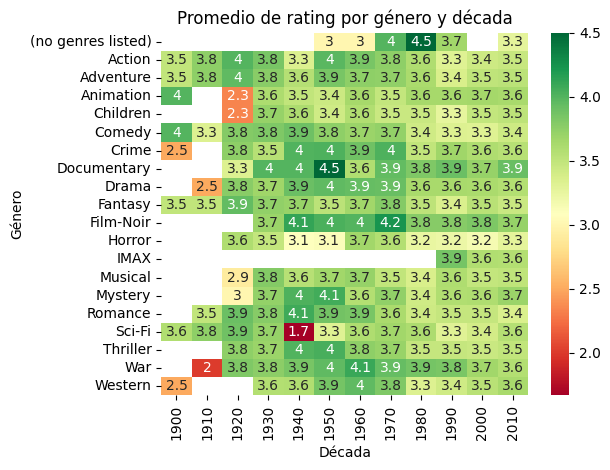

In [1]:
#Mejores generos rankeados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

movies = pd.read_csv("DataBase/movies.csv")
links = pd.read_csv("DataBase/links.csv")
ratings = pd.read_csv("DataBase/ratings.csv")
tags = pd.read_csv("DataBase/tags.csv")

df = pd.merge(ratings, movies, on = 'movieId')

df_genres = df.copy()
df_genres['genres'] = df_genres['genres'].str.split('|')
df_genres = df_genres.explode('genres')
df_genres['year'] = df_genres['title'].str.extract(r'\((\d{4})\)').astype(float)
df_genres['decade'] = (df_genres['year'] // 10 * 10).astype('Int64')

pivot = df_genres.pivot_table(index='genres', columns='decade', values='rating', aggfunc='mean')

plt.Figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, cmap='RdYlGn')
plt.title('Promedio de rating por género y década')
plt.ylabel('Género')
plt.xlabel('Década')
plt.tight_layout()
plt.show()